In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from minisom import MiniSom
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Create directory for plots
output_dir = 'Plots'
os.makedirs(output_dir, exist_ok=True)

In [4]:
# Load the cleaned dataset from Delivery 1
df = pd.read_csv('Data/DM_AIAI_FinalCustomerSegments.csv')
print(f"Raw dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Unique customers: {df['Loyalty#'].nunique():,}")

Raw dataset loaded: 602,532 rows × 40 columns
Unique customers: 16,737


In [5]:
df.head()

,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed,avg_km_per_flight,avg_points_per_flight,redemption_ratio,points_balance,active_days,months_since_flight,companion_ratio,clv_per_flight,clv_to_salary_ratio,loyalty_tier_numeric,preliminary_segment
0,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2019-02-15,NaN,3839.14,Standard,2020,5,2020-05-01,13,4,25010.0,2501.0,0.0,0.0,1786.428571,178.642857,0.0,2501.0,2509,19,0.285714,274.224286,0.05473,1,Dormant
1,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2019-02-15,NaN,3839.14,Standard,2020,4,2020-04-01,0,0,5095.0,509.0,0.0,0.0,5095.000000,509.000000,0.0,509.0,2509,20,0.000000,3839.140000,0.05473,1,Dormant
2,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2019-02-15,NaN,3839.14,Standard,2020,2,2020-02-01,3,0,24271.0,2427.0,0.0,0.0,6067.750000,606.750000,0.0,2427.0,2509,22,0.000000,959.785000,0.05473,1,Dormant
3,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2019-02-15,NaN,3839.14,Standard,2020,3,2020-03-01,0,0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,2509,21,0.000000,3839.140000,0.05473,1,Dormant
4,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2019-02-15,NaN,3839.14,Standard,2020,1,2020-01-01,0,0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,2509,23,0.000000,3839.140000,0.05473,1,Dormant


In [6]:
customer_agg = df.groupby('Loyalty#').agg({
    'Country': lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0],
    'Province or State': lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0],
    'City': lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0],
    'Gender': lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0],
    'Education': lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0],
    'Income': 'first',
    'Marital Status': lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0],
    'LoyaltyStatus': lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0],

    'NumFlights': 'sum',
    'DistanceKM': 'sum',
    'PointsAccumulated': 'sum',
    'PointsRedeemed': 'sum',

    'Customer Lifetime Value': 'first',

    'months_since_flight': 'min',
    'active_days': 'max'
}).reset_index()

customer_agg['avg_km_per_flight'] = customer_agg['DistanceKM'] / customer_agg['NumFlights'].replace(0, 1)
customer_agg['avg_points_per_flight'] = customer_agg['PointsAccumulated'] / customer_agg['NumFlights'].replace(0, 1)
customer_agg['clv_per_flight'] = customer_agg['Customer Lifetime Value'] / customer_agg['NumFlights'].replace(0, 1)

customer_agg['redemption_rate'] = (
    customer_agg['PointsRedeemed'] / customer_agg['PointsAccumulated'].replace(0, 1)
) * 100

df = customer_agg.copy()

In [7]:
# -------------------------------------------------------
# 1) Define perspectives (feature sets)
# -------------------------------------------------------

# ---- feature sets (aligned with your df) ----
behavior_features = [
    "NumFlights",
    "avg_km_per_flight",
    "avg_points_per_flight",
    "months_since_flight",
    "active_days",
    "redemption_rate",
]

value_features = [
    "Customer Lifetime Value",
    "clv_per_flight",
]

demo_features = [
    "Income",
    "Education",
    "Marital Status",
]

# ---- build matrices ----
X_behavior_df = df[behavior_features].copy()
X_value_df = df[value_features].copy()

X_demo_df = df[demo_features].copy()
X_demo_encoded = pd.get_dummies(X_demo_df, columns=["Education", "Marital Status"], drop_first=True)


In [8]:
X_behavior_df.head()

,NumFlights,avg_km_per_flight,avg_points_per_flight,months_since_flight,active_days,redemption_rate
0,231,2295.367965,229.499134,0,2334,38.787271
1,248,1367.397581,136.709516,0,3582,55.334539
2,217,1990.925346,199.044147,0,2344,11.335280
3,112,3255.372321,325.480089,0,2702,35.410878
4,187,2297.489305,229.696524,0,3276,25.356405


In [9]:
X_value_df.head()

,Customer Lifetime Value,clv_per_flight
0,7919.20,34.282251
1,2887.74,11.644113
2,2838.07,13.078664
3,4170.57,37.237232
4,6622.05,35.412032


In [10]:
X_demo_df.head()

,Income,Education,Marital Status
0,82877.0,Bachelor,Married
1,0.0,College,Single
2,0.0,College,Divorced
3,42837.0,Bachelor,Married
4,80979.0,Bachelor,Divorced


In [11]:
scaler = StandardScaler()

X_behavior = StandardScaler().fit_transform(X_behavior_df)
X_value = StandardScaler().fit_transform(X_value_df)
X_demo = StandardScaler().fit_transform(X_demo_encoded)

customer_ids = df["Loyalty#"].values

print("Behavior:", X_behavior.shape, behavior_features)
print("Value:", X_value.shape, value_features)
print("Demo:", X_demo.shape, "encoded_cols=", X_demo_encoded.shape[1])

Behavior: (16737, 6) ['NumFlights', 'avg_km_per_flight', 'avg_points_per_flight', 'months_since_flight', 'active_days', 'redemption_rate']
Value: (16737, 2) ['Customer Lifetime Value', 'clv_per_flight']
Demo: (16737, 7) encoded_cols= 7


In [14]:
# -------------------------------------------------------
# Optimal k for KMeans + Agglomerative (per feature set)
# -------------------------------------------------------
from typing import Iterable, Tuple

def _clustering_metrics(X: np.ndarray, labels: np.ndarray) -> Tuple[float, float, float]:
    sil = silhouette_score(X, labels)
    db = davies_bouldin_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    return float(sil), float(db), float(ch)

def evaluate_k_kmeans(
    X: np.ndarray,
    k_values: Iterable[int] = range(2, 11),
    random_state: int = 42,
    n_init: int = 20,
) -> pd.DataFrame:
    rows = []
    for k in k_values:
        model = KMeans(n_clusters=int(k), random_state=random_state, n_init=n_init)
        labels = model.fit_predict(X)
        sil, db, ch = _clustering_metrics(X, labels)
        rows.append({
            "algorithm": "kmeans",
            "k": int(k),
            "inertia": float(model.inertia_),
            "silhouette": sil,
            "davies_bouldin": db,
            "calinski_harabasz": ch,
        })
    return pd.DataFrame(rows).sort_values("k").reset_index(drop=True)

def evaluate_k_agglomerative(
    X: np.ndarray,
    k_values: Iterable[int] = range(2, 11),
    linkage: str = "ward",
) -> pd.DataFrame:
    rows = []
    for k in k_values:
        # ward requires Euclidean distances and works well with standardized numeric features.
        model = AgglomerativeClustering(n_clusters=int(k), linkage=linkage)
        labels = model.fit_predict(X)
        sil, db, ch = _clustering_metrics(X, labels)
        rows.append({
            "algorithm": f"agglomerative_{linkage}",
            "k": int(k),
            "inertia": np.nan,
            "silhouette": sil,
            "davies_bouldin": db,
            "calinski_harabasz": ch,
        })
    return pd.DataFrame(rows).sort_values("k").reset_index(drop=True)

def pick_best_k(results: pd.DataFrame, metric: str = "silhouette") -> int:
    if metric == "silhouette":
        return int(results.loc[results[metric].idxmax(), "k"])
    if metric in {"davies_bouldin", "inertia"}:
        return int(results.loc[results[metric].idxmin(), "k"])
    return int(results.loc[results[metric].idxmax(), "k"])

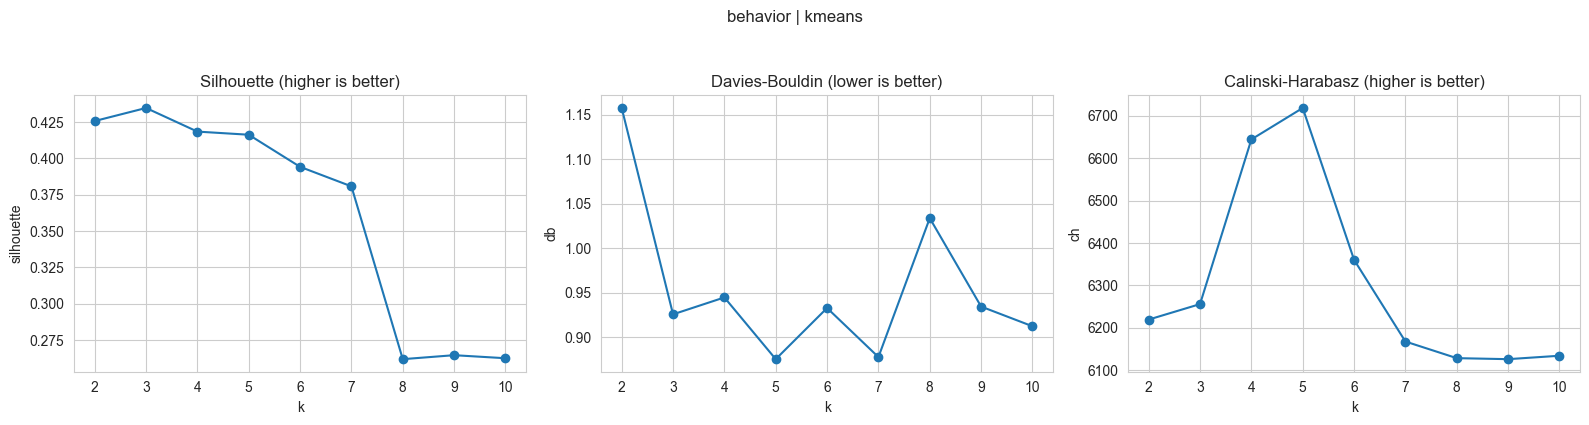

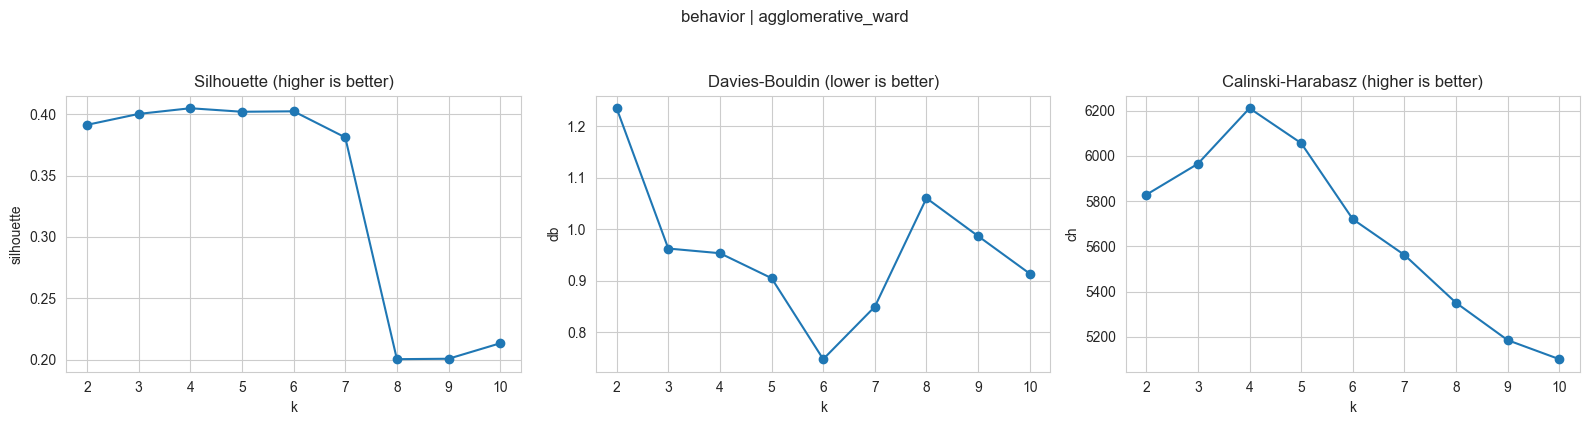

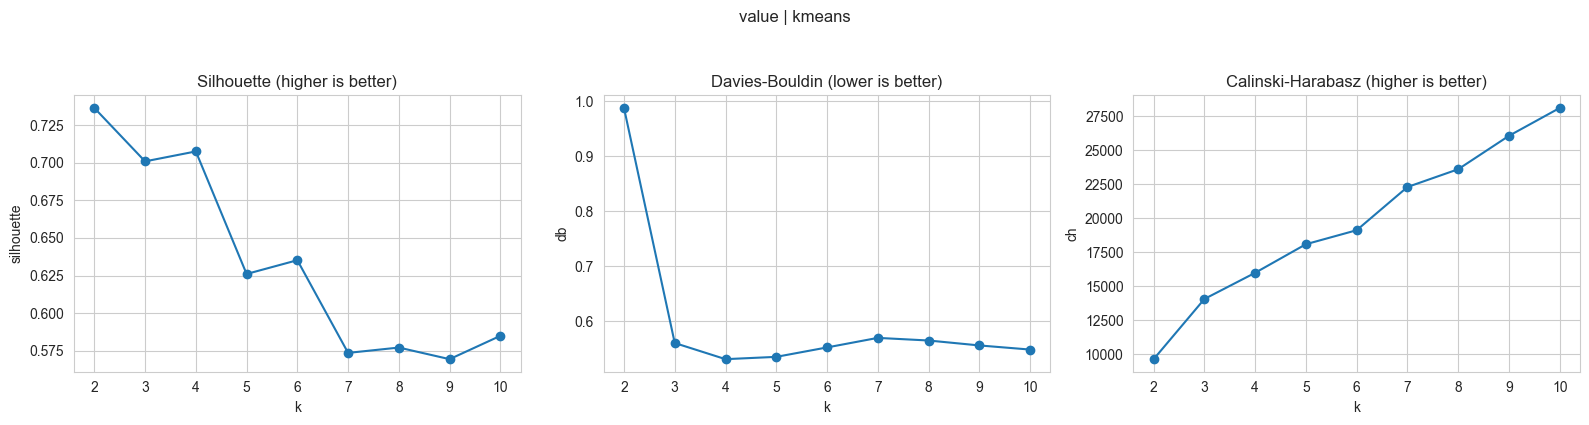

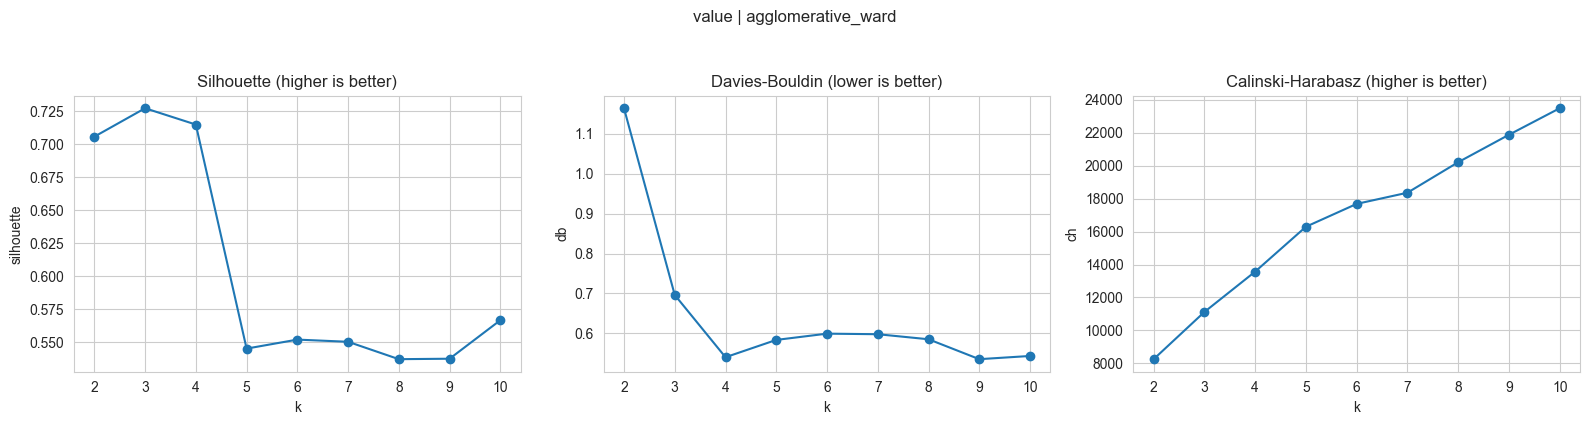

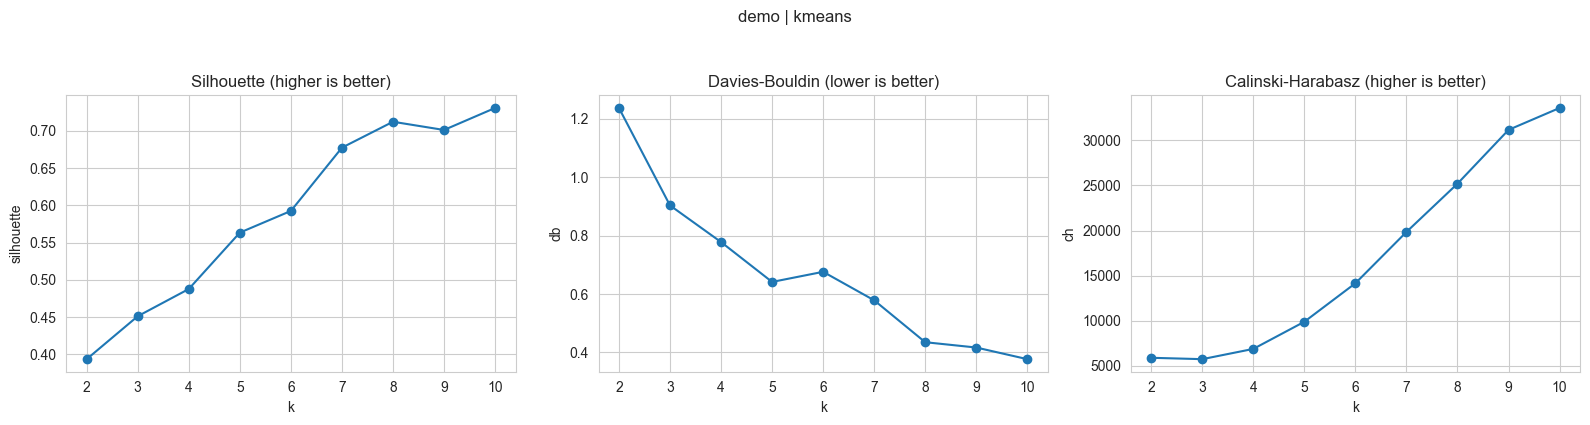

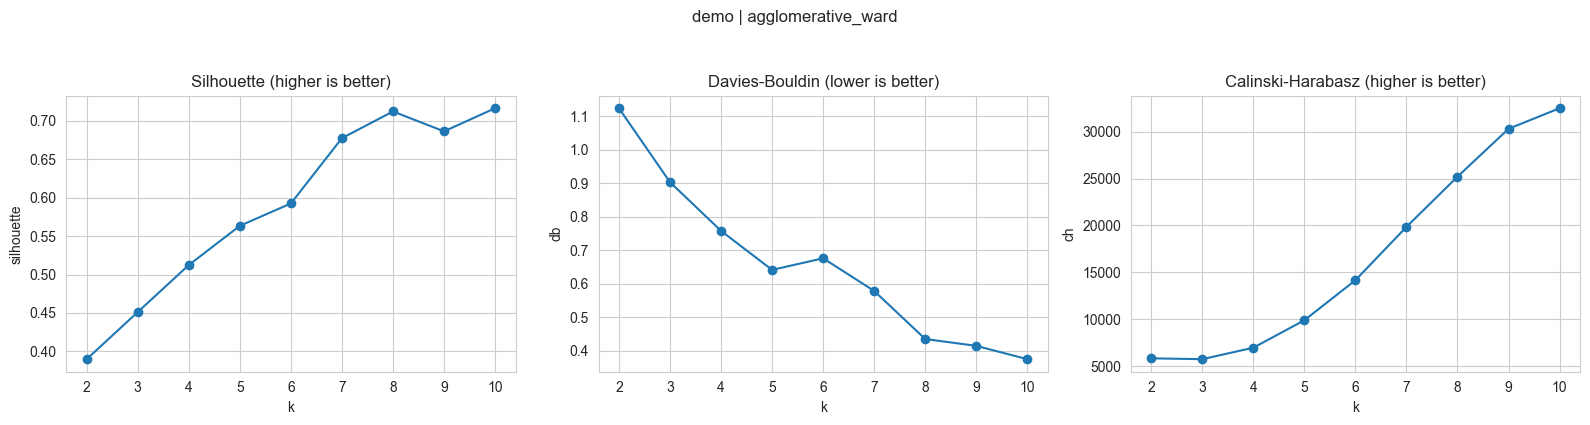

Best k by silhouette:
          kmeans  agglomerative_ward
behavior       3                   4
value          2                   3
demo          10                  10


,algorithm,k,inertia,silhouette,davies_bouldin,calinski_harabasz,feature_set
0,kmeans,2,61010.028767,0.425680,1.157465,6219.728861,behavior
1,kmeans,3,47882.460763,0.434667,0.925747,6256.153564,behavior
2,kmeans,4,38191.945737,0.418422,0.944729,6643.942661,behavior
3,kmeans,5,32112.302823,0.416268,0.875405,6717.943340,behavior
4,kmeans,6,28849.059178,0.394196,0.932844,6360.417434,behavior


In [15]:
# -------------------------------------------------------
# Run k-search for each feature set (KMeans + Agglomerative)
# -------------------------------------------------------
k_values = range(2, 11)

feature_sets = {
    "behavior": X_behavior,
    "value": X_value,
    "demo": X_demo,
}

all_results = []
best_k = {"kmeans": {}, "agglomerative_ward": {}}

for name, X in feature_sets.items():
    # KMeans
    res_km = evaluate_k_kmeans(X, k_values=k_values)
    best_km = pick_best_k(res_km, metric="silhouette")
    best_k["kmeans"][name] = best_km
    all_results.append(res_km.assign(feature_set=name))

    # Agglomerative (Ward)
    res_ag = evaluate_k_agglomerative(X, k_values=k_values, linkage="ward")
    best_ag = pick_best_k(res_ag, metric="silhouette")
    best_k["agglomerative_ward"][name] = best_ag
    all_results.append(res_ag.assign(feature_set=name))

results_df = pd.concat(all_results, ignore_index=True)

# Save a quick metric plot per (feature_set, algorithm)
for (fs, algo), sub in results_df.groupby(["feature_set", "algorithm"], sort=False):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].plot(sub["k"], sub["silhouette"], marker="o")
    axes[0].set_title("Silhouette (higher is better)")
    axes[0].set_xlabel("k")
    axes[0].set_ylabel("silhouette")

    axes[1].plot(sub["k"], sub["davies_bouldin"], marker="o")
    axes[1].set_title("Davies-Bouldin (lower is better)")
    axes[1].set_xlabel("k")
    axes[1].set_ylabel("db")

    axes[2].plot(sub["k"], sub["calinski_harabasz"], marker="o")
    axes[2].set_title("Calinski-Harabasz (higher is better)")
    axes[2].set_xlabel("k")
    axes[2].set_ylabel("ch")

    fig.suptitle(f"{fs} | {algo}", y=1.05)
    fig.tight_layout()
    fig.savefig(os.path.join(output_dir, f"k_search_{fs}_{algo}.png"), dpi=200, bbox_inches="tight")
    plt.show()

print("Best k by silhouette:")
print(pd.DataFrame(best_k))

# If you want to actually FIT the final models later, you can use best_k[...] above.
results_df.head()

In [19]:
# -------------------------------------------------------
# Fit final models using the optimal k (per feature set)
# (Clustering only: creates labels/models/scores)
# -------------------------------------------------------
final_labels = {}
final_models = {}
final_scores = []

for fs_name, X in feature_sets.items():
    # --- KMeans ---
    k_km = int(best_k["kmeans"][fs_name])
    km = KMeans(n_clusters=k_km, random_state=42, n_init=20)
    labels_km = km.fit_predict(X)
    final_models[(fs_name, "kmeans")] = km
    final_labels[(fs_name, "kmeans")] = labels_km
    sil, db, ch = _clustering_metrics(X, labels_km)
    final_scores.append({
        "feature_set": fs_name,
        "algorithm": "kmeans",
        "k": k_km,
        "silhouette": sil,
        "davies_bouldin": db,
        "calinski_harabasz": ch,
    })

    # --- Agglomerative (Ward) ---
    k_ag = int(best_k["agglomerative_ward"][fs_name])
    ag = AgglomerativeClustering(n_clusters=k_ag, linkage="ward")
    labels_ag = ag.fit_predict(X)
    final_models[(fs_name, "agglomerative_ward")] = ag
    final_labels[(fs_name, "agglomerative_ward")] = labels_ag
    sil, db, ch = _clustering_metrics(X, labels_ag)
    final_scores.append({
        "feature_set": fs_name,
        "algorithm": "agglomerative_ward",
        "k": k_ag,
        "silhouette": sil,
        "davies_bouldin": db,
        "calinski_harabasz": ch,
    })

scores_df = pd.DataFrame(final_scores).sort_values(["feature_set", "algorithm"]).reset_index(drop=True)
print("Final model quality (using chosen k):")
display(scores_df)

Final model quality (using chosen k):


,feature_set,algorithm,k,silhouette,davies_bouldin,calinski_harabasz
0,behavior,agglomerative_ward,4,0.404927,0.953419,6210.653040
1,behavior,kmeans,3,0.434667,0.925747,6256.153564
2,demo,agglomerative_ward,10,0.716583,0.374700,32491.327135
3,demo,kmeans,10,0.730937,0.376897,33587.874074
4,value,agglomerative_ward,3,0.727196,0.696220,11121.620854
5,value,kmeans,2,0.736542,0.988216,9621.822833


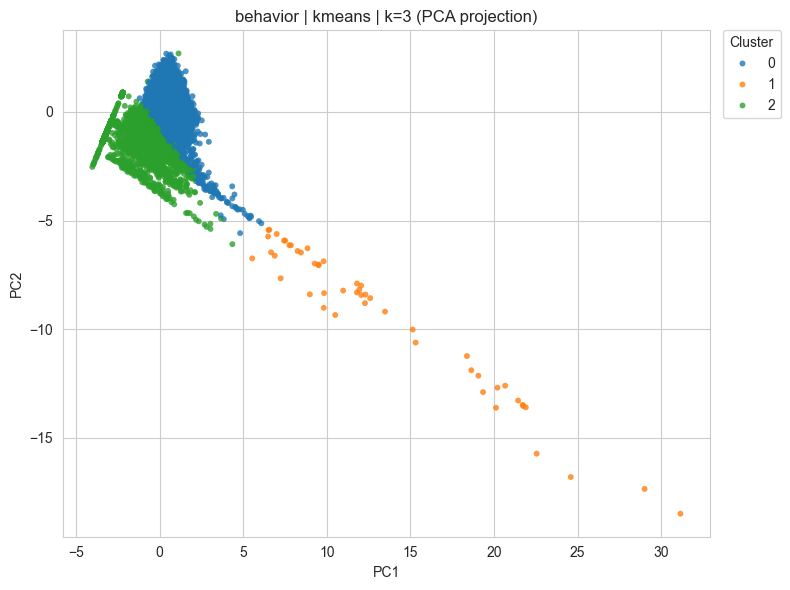

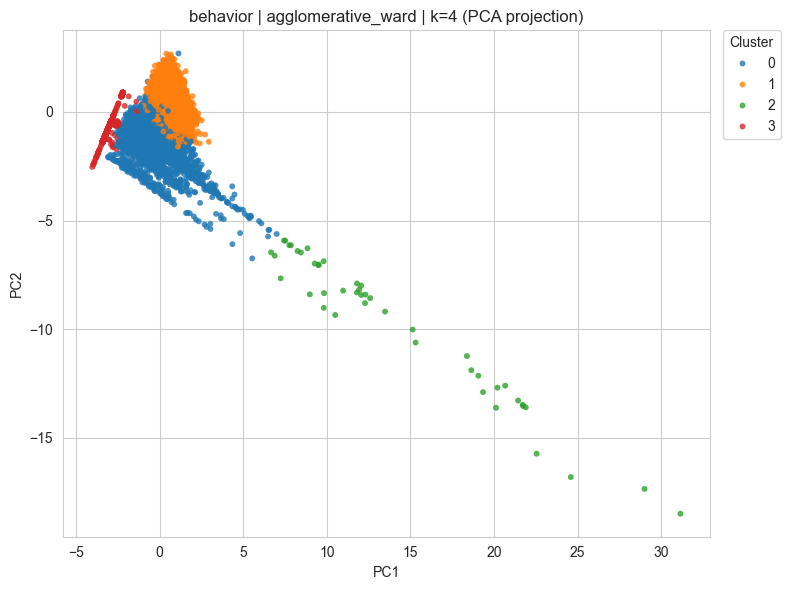

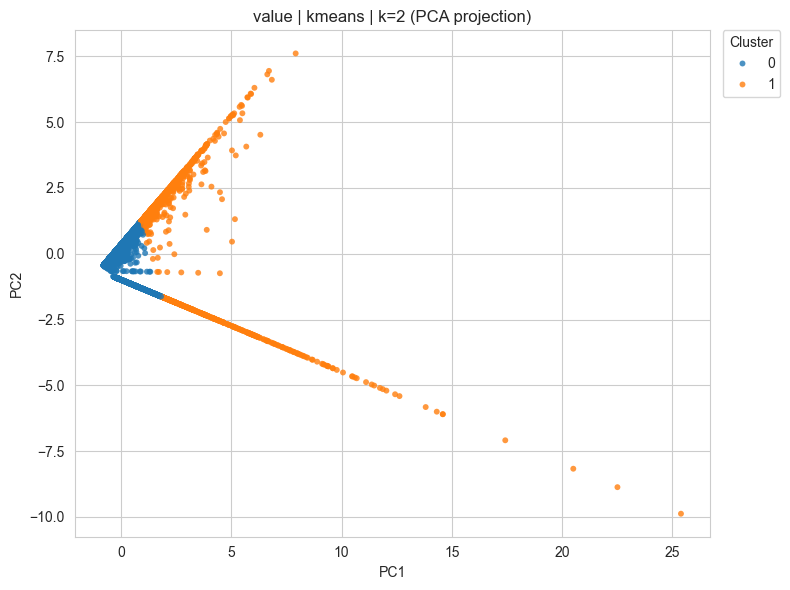

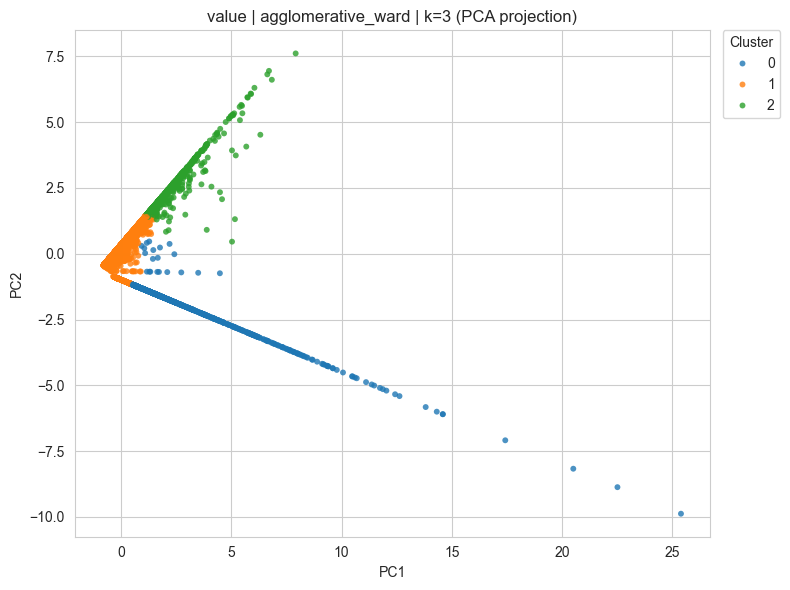

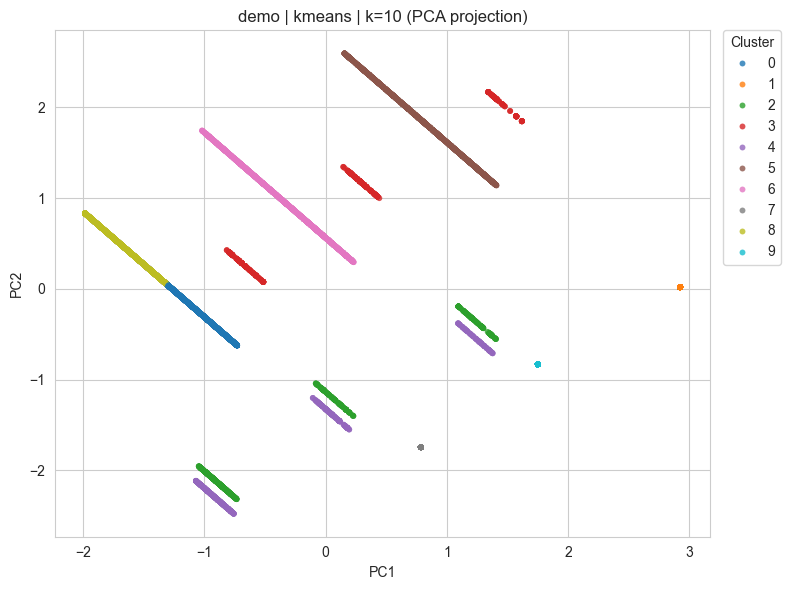

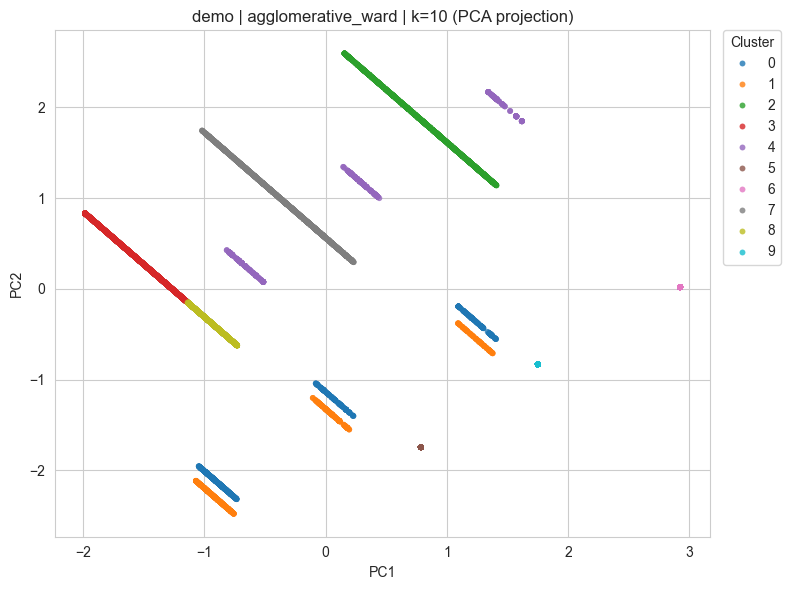

In [20]:
# -------------------------------------------------------
# Visualize separation (PCA 2D) after clustering
# -------------------------------------------------------
def plot_cluster_separation_pca(
    X: np.ndarray,
    labels: np.ndarray,
    title: str,
    save_path: str | None = None,
    show_plot: bool = True,
):
    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X)

    plot_df = pd.DataFrame({
        "pc1": X_2d[:, 0],
        "pc2": X_2d[:, 1],
        "cluster": labels.astype(int),
    })

    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=plot_df,
        x="pc1",
        y="pc2",
        hue="cluster",
        palette="tab10",
        s=18,
        linewidth=0,
        alpha=0.8,
    )
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    if show_plot:
        plt.show()
    else:
        plt.close()

# Generate plots for each feature set & algorithm
for fs_name, X in feature_sets.items():
    for algo_name in ["kmeans", "agglomerative_ward"]:
        labels = final_labels[(fs_name, algo_name)]
        k_used = int(best_k["kmeans"][fs_name]) if algo_name == "kmeans" else int(best_k["agglomerative_ward"][fs_name])
        out_file = os.path.join(output_dir, f"separation_pca_{fs_name}_{algo_name}_k{k_used}.png")
        plot_cluster_separation_pca(
            X,
            labels,
            title=f"{fs_name} | {algo_name} | k={k_used} (PCA projection)",
            save_path=out_file,
            show_plot=True,
        )

In [21]:
# -------------------------------------------------------
# Add cluster labels back to df (separate step)
# -------------------------------------------------------
df = df.copy()

df["cluster_behavior_kmeans"] = final_labels[("behavior", "kmeans")]
df["cluster_value_kmeans"] = final_labels[("value", "kmeans")]
df["cluster_demo_kmeans"] = final_labels[("demo", "kmeans")]

df["cluster_behavior_agglomerative_ward"] = final_labels[("behavior", "agglomerative_ward")]
df["cluster_value_agglomerative_ward"] = final_labels[("value", "agglomerative_ward")]
df["cluster_demo_agglomerative_ward"] = final_labels[("demo", "agglomerative_ward")]

print("Cluster sizes (KMeans):")
display(df[["cluster_behavior_kmeans", "cluster_value_kmeans", "cluster_demo_kmeans"]].apply(pd.Series.value_counts).fillna(0).astype(int))

print("Cluster sizes (Agglomerative Ward):")
display(df[["cluster_behavior_agglomerative_ward", "cluster_value_agglomerative_ward", "cluster_demo_agglomerative_ward"]].apply(pd.Series.value_counts).fillna(0).astype(int))

df.head()

Cluster sizes (KMeans):


,cluster_behavior_kmeans,cluster_value_kmeans,cluster_demo_kmeans
0,11734,15211,3645
1,50,1526,2426
2,4953,0,782
3,0,0,508
4,0,0,734
5,0,0,1719
6,0,0,1644
7,0,0,1436
8,0,0,3467
9,0,0,376


Cluster sizes (Agglomerative Ward):


,cluster_behavior_agglomerative_ward,cluster_value_agglomerative_ward,cluster_demo_agglomerative_ward
0,4292,1046,782
1,10853,14811,734
2,45,880,1719
3,1547,0,4398
4,0,0,508
5,0,0,1436
6,0,0,2426
7,0,0,1644
8,0,0,2714
9,0,0,376


,Loyalty#,Country,Province or State,City,Gender,Education,Income,Marital Status,LoyaltyStatus,NumFlights,DistanceKM,PointsAccumulated,PointsRedeemed,Customer Lifetime Value,months_since_flight,active_days,avg_km_per_flight,avg_points_per_flight,clv_per_flight,redemption_rate,cluster_behavior_kmeans,cluster_value_kmeans,cluster_demo_kmeans,cluster_behavior_agglomerative_ward,cluster_value_agglomerative_ward,cluster_demo_agglomerative_ward
0,100018,Canada,Alberta,Edmonton,female,Bachelor,82877.0,Married,Aurora,231,530230.0,53014.30,20562.8,7919.20,0,2334,2295.367965,229.499134,34.282251,38.787271,0,0,8,1,1,3
1,100102,Canada,Ontario,Toronto,male,College,0.0,Single,Nova,248,339114.6,33903.96,18760.6,2887.74,0,3582,1367.397581,136.709516,11.644113,55.334539,0,0,1,1,1,6
2,100140,Canada,British Columbia,Dawson Creek,female,College,0.0,Divorced,Nova,217,432030.8,43192.58,4896.0,2838.07,0,2344,1990.925346,199.044147,13.078664,11.335280,0,0,9,1,1,9
3,100214,Canada,British Columbia,Vancouver,male,Bachelor,42837.0,Married,Star,112,364601.7,36453.77,12908.6,4170.57,0,2702,3255.372321,325.480089,37.237232,35.410878,0,0,0,1,1,8
4,100272,Canada,Ontario,Toronto,female,Bachelor,80979.0,Divorced,Star,187,429630.5,42953.25,10891.4,6622.05,0,3276,2297.489305,229.696524,35.412032,25.356405,0,0,6,1,1,7
